In [1]:
# import packages needed
import time as tm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import math

from numba import njit
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
from scipy.integrate import odeint
from scipy.optimize import least_squares
from scipy.optimize import leastsq

from sklearn import linear_model
from numpy.linalg import norm

import warnings
warnings.filterwarnings('ignore')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
start_time = tm.time()                                            # start recording runtime
df = pd.read_csv('../Data/coculture.csv')                         # read inputn data
time_seg = 1
cur_time = np.array(df["year"])
interval = [cur_time[i + 1] - cur_time[i] for i in range(len(cur_time) - 1)]
num_point = len(df)
num_iteration = 100                                               # number of iterations in subroutine 1                                 
n0_est = 100                                                      # initial guess of N_sum


@njit
def rhs(X, t, theta):                                              # define gLV system with relative abundances and inter-species sum of absolute abundances
    # unpack parameters
    x, y, n = X
    r1, r2, b12, b21, x0, y0, n0 = theta
    # equations
    dn_dt = r1*x*n + r2*y*n + b12*x*y*n*n + b21*x*y*n*n
    dx_dt = (r1*x*n + b12*x*y*n*n - x*dn_dt)/n
    dy_dt = (r2*y*n + b21*x*y*n*n - y*dn_dt)/n
    
    return [dx_dt, dy_dt, dn_dt]

data = pd.DataFrame(dict(
    n1_relative = df["hare_rel"],
    n2_relative = df["lynx_rel"],
    n1_abs = df["hare_rel"] * n0_est,
    n2_abs = df["lynx_rel"] * n0_est, 
))

for i in range (num_point-1):                                                                              # ilv subroutine 1  step1
    data.loc[num_point+i] = (1/interval[i])*np.log(data.loc[i+1]) - (1/interval[i])*np.log(data.loc[i])

x = pd.DataFrame(data.loc[0:num_point-2, ["n2_abs"]])                                                      # linear regressions
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n1_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r1_ini = regr.intercept_[0]
b12_ini = regr.coef_[0,0]

x = pd.DataFrame(data.loc[0:num_point-2, ["n1_abs"]])
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n2_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r2_ini = regr.intercept_[0]
b21_ini = regr.coef_[0,0]

theta_estimate = np.array([r1_ini, r2_ini, b12_ini, b21_ini, df.iloc[0, -2], df.iloc[0, -1], n0_est])

real_value = pd.DataFrame(dict(
    n1_relative = df.iloc[:len(cur_time), -2],
    n2_relative = df.iloc[:len(cur_time), -1],
))


NM = num_iteration
distance = [None] * NM
distance_min = np.inf
theta_min = theta_estimate

for m in range(NM):                                                                       # NM loops in ilv subroutine 1, step 2
    theta = theta_estimate
    time = cur_time
        
    x_y_hat = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))
    dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y_hat[:, 0]))**2
    dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y_hat[:, 1]))**2
    distance[m] = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)
    if distance[m] < distance_min:
        distance_min = distance[m]
        theta_min = theta_estimate                                                       # record best results in NM loops
    
    data = pd.DataFrame(dict(
        n1_relative = np.array(x_y_hat[:, 0]),
        n2_relative = np.array(x_y_hat[:, 1]),
        absolute_sum = np.array(x_y_hat[:, 2]),
        n1_abs = np.array(df["hare_rel"]) * np.array(x_y_hat[:, 2]),
        n2_abs = np.array(df["lynx_rel"]) * np.array(x_y_hat[:, 2]),
)) 

    for i in range (num_point-1):
        data.loc[num_point+i] = (1/interval[i])*np.log(data.loc[i+1]) - (1/interval[i])*np.log(data.loc[i])
        
    x = pd.DataFrame(data.loc[0:num_point-2, ["n2_abs"]])
    y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n1_abs"])
    regr = linear_model.LinearRegression()
    regr.fit(x, y)
    r1_hat = regr.intercept_[0]
    b12_hat = regr.coef_[0,0]
    
    x = pd.DataFrame(data.loc[0:num_point-2, ["n1_abs"]])
    y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n2_abs"])
    regr = linear_model.LinearRegression()
    regr.fit(x, y)
    r2_hat = regr.intercept_[0]
    b21_hat = regr.coef_[0,0]
    theta_estimate = np.array([r1_hat, r2_hat, b12_hat, b21_hat, df.iloc[0, -2], df.iloc[0, -1], n0_est]) 


# function that calculates residuals based on a given theta
def ode_model_resid(thetab):
    return (
        np.abs(df[["hare_rel", "lynx_rel"]] - np.delete(odeint(func=rhs, y0=thetab[-3:], t=time, args=(thetab,)), -1, axis=1))
    ).values.flatten()


method_used = "None"
distance_sq = [None]
distance_trf = [None]
distance_lm = [None]

theta_est = theta_min

results = leastsq(ode_model_resid, x0=theta_est)
theta = results[0]
time = cur_time


# compare the results of three optimization methods in subroutine 2 and return the best one.
# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y[:, 0]))**2
dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y[:, 1]))**2
distance_sq = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)
if distance_sq < distance_min:
    distance_min = distance_sq
    theta_min = results[0]
    method_used = "sq"


results = least_squares(ode_model_resid, x0=theta_est, method = 'trf')
theta = results.x
time = cur_time

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y[:, 0]))**2
dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y[:, 1]))**2
distance_trf = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)
if distance_trf < distance_min:
    distance_min = distance_trf
    theta_min = results.x
    method_used = "trf"



results = least_squares(ode_model_resid, x0=theta_est, method = 'lm')
theta = results.x
time = cur_time

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y[:, 0]))**2
dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y[:, 1]))**2
distance_lm = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)
if distance_lm < distance_min:
    distance_min = distance_lm
    theta_min = results.x
    method_used = "lm"

In [3]:
end_time = tm.time()
print(f"Run time: {end_time - start_time:.8f} seconds")       # record runtime

Run time: 3.03567982 seconds


In [4]:
distance_min                                        # report RMSE of ilv

0.06728212223360934

In [5]:
# plot model function
def plot_model(
    ax,
    x_y,
    time=cur_time,
    alpha=0.5,
    lw=1,
):
    ax.plot(time, x_y[:, 0], color="red", alpha=alpha, lw=lw, label="Estimated S.p. relative")
    ax.plot(time, x_y[:, 1], color="blue", alpha=alpha, lw=lw, label="Estimated P.c. relative")
    ax.legend(fontsize=16)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    return ax

In [6]:
# plot data function
def plot_data(ax, lw=1, time=cur_time):
    ax.plot(time, df.hare_rel, color="red", marker="o", label="Observed S.p. relative", linestyle="None", markersize=6)
    ax.plot(time, df.lynx_rel, color="blue", marker="+", label="Observed P.c. relative", linestyle="None", markersize=6)
    ax.legend(fontsize=18)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlim([0, len(cur_time)*time_seg])
    ax.set_xlabel("Time", fontsize = 18)
    ax.set_ylabel("Relative abundance", fontsize = 18)
    ax.set_xticks(time.astype(int))
    ax.set_xticklabels(ax.get_xticks())
    ax.tick_params(axis='both', labelsize=16)
    return ax

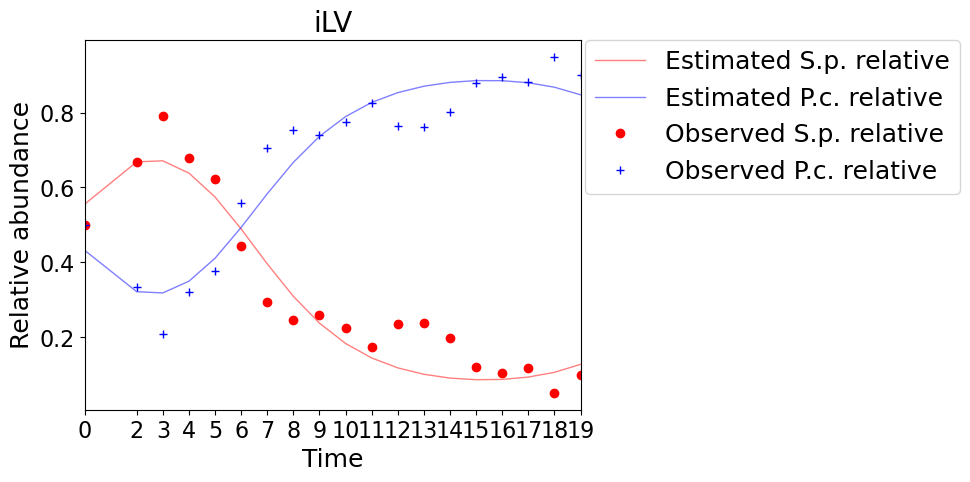

In [7]:
theta = theta_min
time = cur_time

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

# plot
_, ax = plt.subplots()
plot_model(ax, x_y);
plot_data(ax, lw=1)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=18)
plt.title("iLV", fontsize = 20)
plt.savefig("Fig4_1.pdf", dpi=300, bbox_inches="tight")     # plot results of ilv

In [8]:
# calculate results for glv_relative

distance_glvr = np.inf
data = pd.DataFrame(dict(
    n1_relative = df["hare_rel"],
    n2_relative = df["lynx_rel"],
    n1_abs = df["hare_rel"] * n0_est,
    n2_abs = df["lynx_rel"] * n0_est, 
))

for i in range (num_point-1):
    data.loc[num_point+i] = (1/interval[i])*np.log(data.loc[i+1]) - (1/interval[i])*np.log(data.loc[i])

x = pd.DataFrame(data.loc[0:num_point-2, ["n2_abs"]])
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n1_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r1_ini = regr.intercept_[0]
b12_ini = regr.coef_[0,0]

x = pd.DataFrame(data.loc[0:num_point-2, ["n1_abs"]])
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n2_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r2_ini = regr.intercept_[0]
b21_ini = regr.coef_[0,0]

theta_glvr = np.array([r1_ini, r2_ini, b12_ini, b21_ini, df.iloc[0, -2], df.iloc[0, -1], n0_est])

real_value = pd.DataFrame(dict(
    n1_relative = df.iloc[:len(cur_time), -2],
    n2_relative = df.iloc[:len(cur_time), -1],
))

theta = theta_glvr
time = cur_time
x_y_hat = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))
dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y_hat[:, 0]))**2
dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y_hat[:, 1]))**2
distance_glvr = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)

In [9]:
distance_glvr                       # rmse of glv_relative

0.1626768534578759

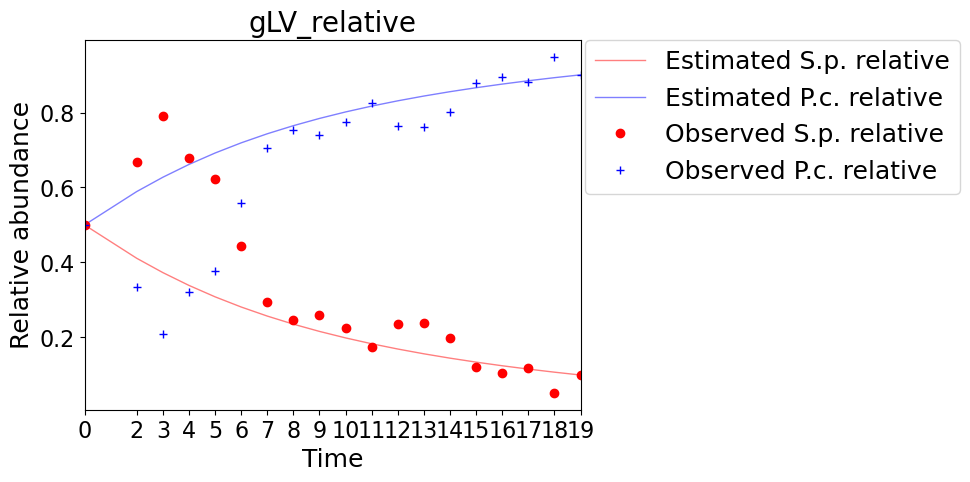

In [10]:
theta = theta_glvr
time = cur_time

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

# plot
_, ax = plt.subplots()
plot_model(ax, x_y);
plot_data(ax, lw=1)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=18)
plt.title("gLV_relative", fontsize = 20)
plt.savefig("Fig4_2.pdf", dpi=300, bbox_inches="tight")               #plot results for glv_relative

In [11]:
distance_glva = np.inf                                         # calulate rmse for glv_absolute
data = pd.DataFrame(dict(
    n1_abs = df["hare_abs"],
    n2_abs = df["lynx_abs"], 
))

for i in range (num_point-1):
    data.loc[num_point+i] = (1/interval[i])*np.log(data.loc[i+1]) - (1/interval[i])*np.log(data.loc[i])

x = pd.DataFrame(data.loc[0:num_point-2, ["n2_abs"]])
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n1_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r1_ini = regr.intercept_[0]
b12_ini = regr.coef_[0,0]

x = pd.DataFrame(data.loc[0:num_point-2, ["n1_abs"]])
y = pd.DataFrame(data.loc[num_point:2*num_point-2, "n2_abs"])

regr = linear_model.LinearRegression()
regr.fit(x, y)

r2_ini = regr.intercept_[0]
b21_ini = regr.coef_[0,0]

theta_glva = np.array([r1_ini, r2_ini, b12_ini, b21_ini, df.iloc[0, -2], df.iloc[0, -1], df.iloc[0, 1] + df.iloc[0, 2]])

real_value = pd.DataFrame(dict(
    n1_relative = df.iloc[:len(cur_time), -2],
    n2_relative = df.iloc[:len(cur_time), -1],
))

theta = theta_glva
time = cur_time
x_y_hat = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))
dis_one = (np.array(np.array(real_value.iloc[:, 0]) - x_y_hat[:, 0]))**2
dis_two = (np.array(np.array(real_value.iloc[:, 1]) - x_y_hat[:, 1]))**2
distance_glva = math.sqrt((np.sum(np.abs(dis_one)) + np.sum(np.abs(dis_two)))/num_point/2)

In [12]:
distance_glva          # report rmse for glv_absolute

0.3829750243951838

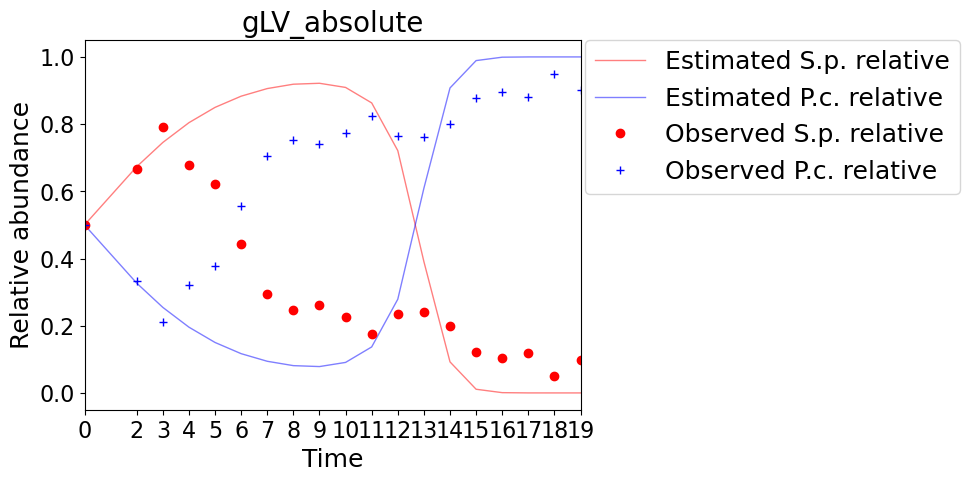

In [13]:
theta = theta_glva
time = cur_time

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-3:], t=time, args=(theta,))

# plot
_, ax = plt.subplots()
plot_model(ax, x_y);
plot_data(ax, lw=1)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=18)
plt.title("gLV_absolute", fontsize = 20)
plt.savefig("Fig4_3.pdf", dpi=300, bbox_inches="tight")                   # plot results for glv_absolute